# Exercise 2: Distributed Sales Data Analysis using PySpark

**Objectives:**
- Load the Retail Transactions dataset
- Perform distributed analysis with Spark
- Apply cleaning, grouping and aggregation
- Visualize aggregated results

**Tasks:**
1. Load dataset
2. Clean missing / invalid values
3. Compute total sales, top countries/products, average sales
4. Visualize results
5. Explain how Spark distributes processing

## 0. Setup & Load Dataset
Initialize Spark and load `data/Retail_Transactions_Dataset.csv`. The notebook detects the available column names and adapts calculations accordingly.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder \
    .appName("Sales Analysis Project") \
    .getOrCreate()

data_path = "../data/Retail_Transactions_Dataset.csv"

# Load dataset with header and inferred schema
sales_df = spark.read.csv(data_path, header=True, inferSchema=True)
print("Schema after initial load:")
sales_df.printSchema()
print(f"Total records: {sales_df.count()}")

Schema after initial load:
root
 |-- Transaction_ID: integer (nullable = true)
 |-- Date: timestamp (nullable = true)
 |-- Customer_Name: string (nullable = true)
 |-- Product: string (nullable = true)
 |-- Total_Items: integer (nullable = true)
 |-- Total_Cost: double (nullable = true)
 |-- Payment_Method: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Store_Type: string (nullable = true)
 |-- Discount_Applied: boolean (nullable = true)
 |-- Customer_Category: string (nullable = true)
 |-- Season: string (nullable = true)
 |-- Promotion: string (nullable = true)

Total records: 1000000


## Task 1: Inspect and normalize column names
We'll detect which columns are present and create a small mapping to use later in the notebook.

In [2]:
cols = sales_df.columns
print("Columns in dataset:", cols)

def find_col(*names):
    for name in names:
        for c in cols:
            if c.lower() == name.lower():
                return c
    return None

# Common candidates (adjust as needed)
transaction_col = find_col('transaction_id', 'Transaction_ID', 'InvoiceNo')
product_col = find_col('product_id', 'Product', 'StockCode')
description_col = find_col('description', 'Description')
quantity_col = find_col('quantity', 'Total_Items')
unit_price_col = find_col('unit_price', 'UnitPrice')
total_cost_col = find_col('total_cost', 'Total_Cost', 'TotalPrice', 'Total_Price')
country_col = find_col('country', 'Country', 'City')
customer_col = find_col('customer_id', 'CustomerID', 'Customer_Name')

print('Detected mapping:' , {
    'transaction_col': transaction_col,
    'product_col': product_col,
    'description_col': description_col,
    'quantity_col': quantity_col,
    'unit_price_col': unit_price_col,
    'total_cost_col': total_cost_col,
    'country_col': country_col,
    'customer_col': customer_col
})

Columns in dataset: ['Transaction_ID', 'Date', 'Customer_Name', 'Product', 'Total_Items', 'Total_Cost', 'Payment_Method', 'City', 'Store_Type', 'Discount_Applied', 'Customer_Category', 'Season', 'Promotion']
Detected mapping: {'transaction_col': 'Transaction_ID', 'product_col': 'Product', 'description_col': None, 'quantity_col': 'Total_Items', 'unit_price_col': None, 'total_cost_col': 'Total_Cost', 'country_col': 'City', 'customer_col': 'Customer_Name'}


## Task 2: Clean missing / invalid values
Drop rows missing the numeric fields we need and remove non-positive quantities (returns).

In [3]:
# Start with a copy reference
clean_sales_df = sales_df

# Drop rows missing total-cost-equivalent or quantity/unit-price pair
if total_cost_col is not None:
    clean_sales_df = clean_sales_df.dropna(subset=[total_cost_col])
else:
    clean_sales_df = clean_sales_df.dropna(subset=[c for c in (quantity_col, unit_price_col) if c is not None])

# If we have a quantity column, ensure it's numeric and > 0
from pyspark.sql.functions import col
if quantity_col is not None:
    clean_sales_df = clean_sales_df.withColumn(quantity_col, col(quantity_col).cast('double')).filter(col(quantity_col) > 0)

# Ensure unit price is numeric when present
if unit_price_col is not None:
    clean_sales_df = clean_sales_df.withColumn(unit_price_col, col(unit_price_col).cast('double'))

print(f"Total records after cleaning: {clean_sales_df.count()}")

Total records after cleaning: 1000000


## Task 3: Compute Aggregations
Compute total sales, top countries, top products and average per-transaction sales using available columns.

In [ ]:
# Using PySpark
from pyspark.sql.functions import col, sum as spark_sum, avg, desc

# Compute total_price from the best available columns
if total_cost_col is not None:
    sales_with_total = clean_sales_df.withColumn('total_price', col(total_cost_col).cast('double'))
elif quantity_col is not None and unit_price_col is not None:
    sales_with_total = clean_sales_df.withColumn('total_price', col(quantity_col).cast('double') * col(unit_price_col).cast('double'))
else:
    raise ValueError('Cannot compute total_price: dataset lacks Total_Cost and Quantity+UnitPrice columns')

# 1. Total Sales overall
total_sales_value = sales_with_total.select(spark_sum('total_price')).collect()[0][0]
print(f"Total Sales: ${total_sales_value:,.2f}\n")

# 2. Top countries by sales (if we have a country-like column)
if country_col is not None:
    country_sales = sales_with_total.groupBy(country_col) \
        .agg(spark_sum('total_price').alias('country_total_sales')) \
        .orderBy(desc('country_total_sales'))
    print("Top countries by sales:")
    country_sales.show(10)
else:
    country_sales = None

# 3. Top products by sales (group by product id and/or description)
group_cols = []
if product_col is not None: group_cols.append(product_col)
if description_col is not None and description_col not in group_cols: group_cols.append(description_col)
if group_cols:
    product_sales = sales_with_total.groupBy(*group_cols) \
        .agg(spark_sum('total_price').alias('product_total_sales')) \
        .orderBy(desc('product_total_sales'))
    print("Top products by sales:")
    product_sales.show(10)
else:
    product_sales = None

# 4. Average sales per transaction/invoice (if transaction id exists)
if transaction_col is not None:
    invoice_totals = sales_with_total.groupBy(transaction_col).agg(spark_sum('total_price').alias('invoice_total'))
    avg_sales_value = invoice_totals.select(avg('invoice_total')).collect()[0][0]
    print(f"Average Sales per Transaction: ${avg_sales_value:,.2f}")
else:
    print('Transaction identifier not found; skipping average-per-transaction')

Total Sales: $52,455,220.40

Top countries by sales:
+-------------+-------------------+
|         City|country_total_sales|
+-------------+-------------------+
|       Dallas|  5277111.529999993|
|       Boston|  5263307.959999998|
|      Chicago|  5263187.450000001|
|     New York|  5252469.920000003|
|      Houston|  5247054.780000003|
|San Francisco|  5241099.859999994|
|        Miami|  5240498.440000004|
|      Seattle|         5235365.43|
|  Los Angeles|  5232393.190000005|
|      Atlanta| 5202731.8400000045|
+-------------+-------------------+

Top products by sales:
+--------------+-------------------+
|       Product|product_total_sales|
+--------------+-------------------+
|['Toothpaste']|          253689.01|
|     ['Honey']| 135409.84999999998|
| ['Deodorant']|          133082.77|
|     ['Pasta']|          131765.69|
|      ['Eggs']| 131565.71000000002|
|   ['Vinegar']|          131538.39|
|      ['Soap']|          131183.28|
|    ['Razors']| 130956.56999999996|
|    ['Salmo

## Task 4: Visualize Results
Collect small aggregated tables to Pandas and plot with Matplotlib/Seaborn.

C:\Users\ngt32\AppData\Local\Temp\ipykernel_15720\4035456558.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country_total_sales', y=x_col, data=country_pd, palette='Blues_d')


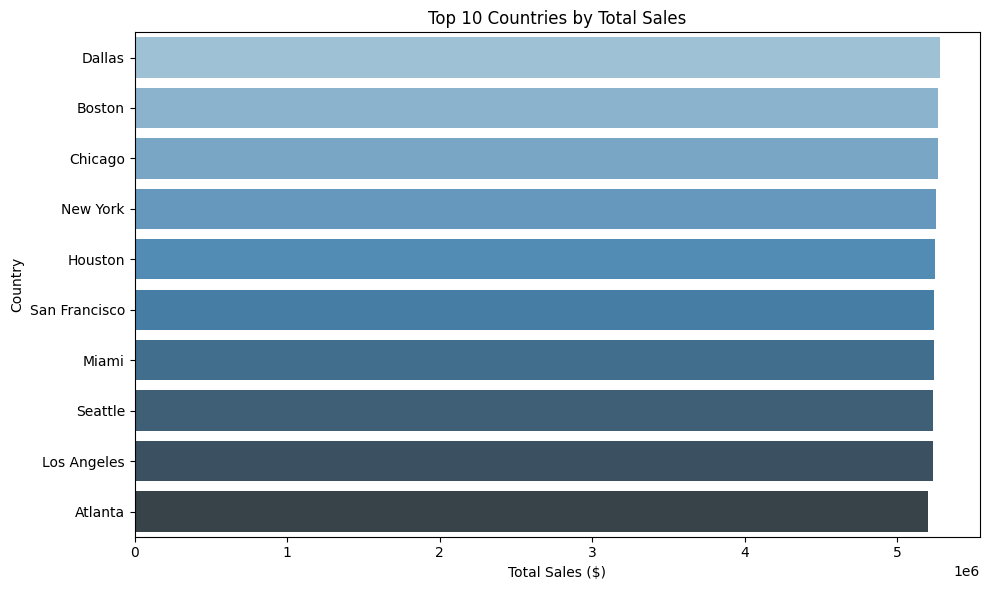

C:\Users\ngt32\AppData\Local\Temp\ipykernel_15720\4035456558.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_total_sales', y=label_col, data=prod_pd, palette='Greens_d')


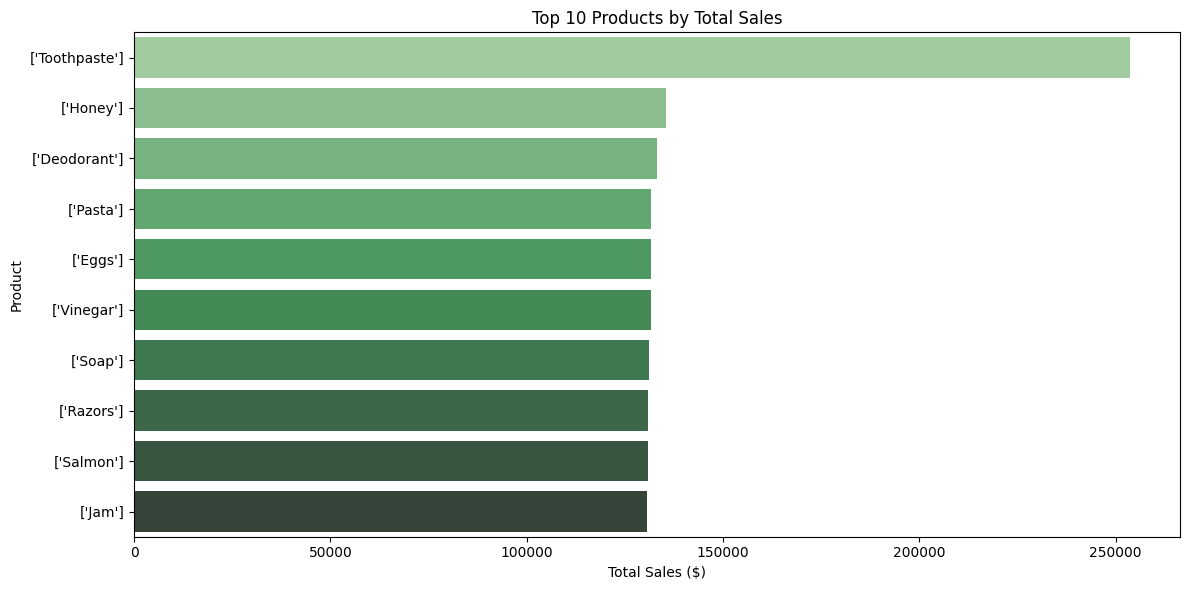

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot top countries if available
if 'country_sales' in globals() and country_sales is not None:
    country_pd = country_sales.limit(10).toPandas()
    x_col = country_pd.columns[0]
    plt.figure(figsize=(10,6))
    sns.barplot(x='country_total_sales', y=x_col, data=country_pd, palette='Blues_d')
    plt.title('Top 10 Countries by Total Sales')
    plt.xlabel('Total Sales ($)')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.show()
else:
    print('No country sales to plot')

# Plot top products if available
if 'product_sales' in globals() and product_sales is not None:
    prod_pd = product_sales.limit(10).toPandas()
    # choose a label column (prefer description)
    label_col = None
    for c in prod_pd.columns:
        if c.lower() in ('description', 'product', 'product_id'):
            label_col = c
            break
    if label_col is None: label_col = prod_pd.columns[0]
    plt.figure(figsize=(12,6))
    sns.barplot(x='product_total_sales', y=label_col, data=prod_pd, palette='Greens_d')
    plt.title('Top 10 Products by Total Sales')
    plt.xlabel('Total Sales ($)')
    plt.ylabel('Product')
    plt.tight_layout()
    plt.show()
else:
    print('No product sales to plot')

## Task 5: How Spark distributes processing
- Spark splits data into partitions distributed to executors and performs transformations lazily. Aggregations may trigger shuffles where partitions exchange data across the network. We reduce to small summary tables and then collect them to the driver for plotting.